In [1]:
# Cell 1: Setup
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import json

# Set your data path
DATA_DIR = Path('cholec80')

print(f"Looking for data in: {DATA_DIR}")
print(f"Directory exists: {DATA_DIR.exists()}")

Looking for data in: cholec80
Directory exists: True


In [4]:
# Cell 2: Comprehensive directory inspection
if DATA_DIR.exists():
    print(f"📁 Exploring: {DATA_DIR}\n")
    
    # List ALL files and folders with their types
    all_items = list(DATA_DIR.rglob('*'))  # Recursive search
    
    print(f"Total items found: {len(all_items)}\n")
    
    # Categorize by type
    folders = [x for x in all_items if x.is_dir()]
    files = [x for x in all_items if x.is_file()]
    
    print(f"📂 Folders: {len(folders)}")
    for folder in folders[:10]:
        print(f"  - {folder.relative_to(DATA_DIR)}")
    
    print(f"\n📄 Files: {len(files)}")
    
    # Group by extension
    from collections import defaultdict
    extensions = defaultdict(list)
    for f in files:
        ext = f.suffix.lower() if f.suffix else 'no_extension'
        extensions[ext].append(f)
    
    print(f"\nFiles by extension:")
    for ext, file_list in sorted(extensions.items()):
        print(f"  {ext}: {len(file_list)} files")
        # Show first 2 examples
        for example in file_list[:2]:
            print(f"    - {example.relative_to(DATA_DIR)}")
    
    # Specifically look for video files (common formats)
    video_extensions = ['.mp4', '.avi', '.mov', '.mkv', '.m4v', '.webm']
    videos = [f for f in files if f.suffix.lower() in video_extensions]
    
    print(f"\n🎥 Video files found: {len(videos)}")
    
    # Look for annotation files
    annotation_extensions = ['.txt', '.json', '.xml', '.csv', '.ann']
    annotations = [f for f in files if f.suffix.lower() in annotation_extensions]
    
    print(f"📝 Annotation files found: {len(annotations)}")
    for a in annotations[:5]:
        print(f"  - {a.relative_to(DATA_DIR)}")
        
else:
    print("❌ Data directory not found!")
    print(f"Expected path: {DATA_DIR}")
    print("\nYou need to:")
    print("1. Download Cholec80 from http://camma.u-strasbg.fr/datasets")
    print("2. Place videos in the correct directory")
    print("3. Update DATA_DIR path if needed")

📁 Exploring: cholec80

Total items found: 4523

📂 Folders: 42
  - MedSAM
  - .ipynb_checkpoints
  - phase_annotations
  - videos
  - output
  - tool_annotations
  - checkpoints
  - MedSAM/work_dir
  - MedSAM/extensions
  - MedSAM/comparisons

📄 Files: 4481

Files by extension:
  .gif: 3 files
    - MedSAM/assets/seg_demo.gif
    - MedSAM/extensions/text_prompt/text_seg_demo.gif
  .idx: 1 files
    - MedSAM/.git/objects/pack/pack-1a74adfaec9144e3714f5e03c0b7d3edc616945b.idx
  .ipynb: 5 files
    - v1.ipynb
    - MedSAM/tutorial_quickstart.ipynb
  .jpg: 1185 files
    - output/video01_medsam/frames/frame_018100.jpg
    - output/video01_medsam/frames/frame_023575.jpg
  .json: 1 files
    - output/video01_medsam/summary.json
  .md: 9 files
    - MedSAM/README.md
    - MedSAM/utils/README.md
  .mp4: 81 files
    - videos/video31.mp4
    - videos/video68.mp4
  .pack: 1 files
    - MedSAM/.git/objects/pack/pack-1a74adfaec9144e3714f5e03c0b7d3edc616945b.pack
  .pdf: 1 files
    - MedSAM/assets/

In [5]:
# Cell 3: Load and inspect a single video
# Pick the first video (or specify one you have)
if len(videos) > 0:
    video_path = videos[0]
    print(f"Analyzing: {video_path.name}\n")
    
    cap = cv2.VideoCapture(str(video_path))
    
    # Get video properties
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = frame_count / fps
    
    print(f"Video Properties:")
    print(f"  Resolution: {width} x {height}")
    print(f"  FPS: {fps}")
    print(f"  Total frames: {frame_count:,}")
    print(f"  Duration: {duration/60:.1f} minutes ({duration:.1f} seconds)")
    print(f"  Size: {video_path.stat().st_size / (1024**3):.2f} GB")
    
    cap.release()
else:
    print("❌ No video files found!")

Analyzing: video31.mp4

Video Properties:
  Resolution: 854 x 480
  FPS: 25.0
  Total frames: 98,626
  Duration: 65.8 minutes (3945.0 seconds)
  Size: 1.49 GB


In [6]:
# Cell 3: Inspect annotation format
import random

print("📋 ANNOTATION FILE FORMATS\n")

# Check phase annotation format
phase_dir = DATA_DIR / "phase_annotations"
if phase_dir.exists():
    sample_phase = random.choice(list(phase_dir.glob('*.txt')))
    print(f"Phase Annotation Sample: {sample_phase.name}")
    print("-" * 50)
    with open(sample_phase, 'r') as f:
        lines = f.readlines()
        print(f"Total lines: {len(lines)}")
        print("\nFirst 10 lines:")
        for i, line in enumerate(lines[:10], 1):
            print(f"  {i}: {line.strip()}")
    print()

# Check tool annotation format
tool_dir = DATA_DIR / "tool_annotations"
if tool_dir.exists():
    sample_tool = random.choice(list(tool_dir.glob('*.txt')))
    print(f"\nTool Annotation Sample: {sample_tool.name}")
    print("-" * 50)
    with open(sample_tool, 'r') as f:
        lines = f.readlines()
        print(f"Total lines: {len(lines)}")
        print("\nFirst 10 lines:")
        for i, line in enumerate(lines[:10], 1):
            print(f"  {i}: {line.strip()}")

# Video info
video_dir = DATA_DIR / "videos"
sample_video = list(video_dir.glob('*.mp4'))[0]
print(f"\n🎥 Sample Video: {sample_video.name}")
print(f"Size: {sample_video.stat().st_size / (1024**3):.2f} GB")

📋 ANNOTATION FILE FORMATS

Phase Annotation Sample: video66-phase.txt
--------------------------------------------------
Total lines: 45602

First 10 lines:
  1: Frame	Phase
  2: 0	Preparation
  3: 1	Preparation
  4: 2	Preparation
  5: 3	Preparation
  6: 4	Preparation
  7: 5	Preparation
  8: 6	Preparation
  9: 7	Preparation
  10: 8	Preparation


Tool Annotation Sample: video48-tool.txt
--------------------------------------------------
Total lines: 1835

First 10 lines:
  1: Frame	Grasper	Bipolar	Hook	Scissors	Clipper	Irrigator	SpecimenBag
  2: 0	0	0	0	0	0	0	0
  3: 25	0	0	0	0	0	0	0
  4: 50	0	0	0	0	0	0	0
  5: 75	0	0	0	0	0	0	0
  6: 100	0	0	0	0	0	0	0
  7: 125	0	0	0	0	0	0	0
  8: 150	0	0	0	0	0	0	0
  9: 175	0	0	0	0	0	0	0
  10: 200	0	0	0	0	0	0	0

🎥 Sample Video: video31.mp4
Size: 1.49 GB



Extracting frames from: video01.mp4

📹 Video: video01.mp4
   Total frames: 43326
   FPS: 25.00
   Duration: 28.88 minutes


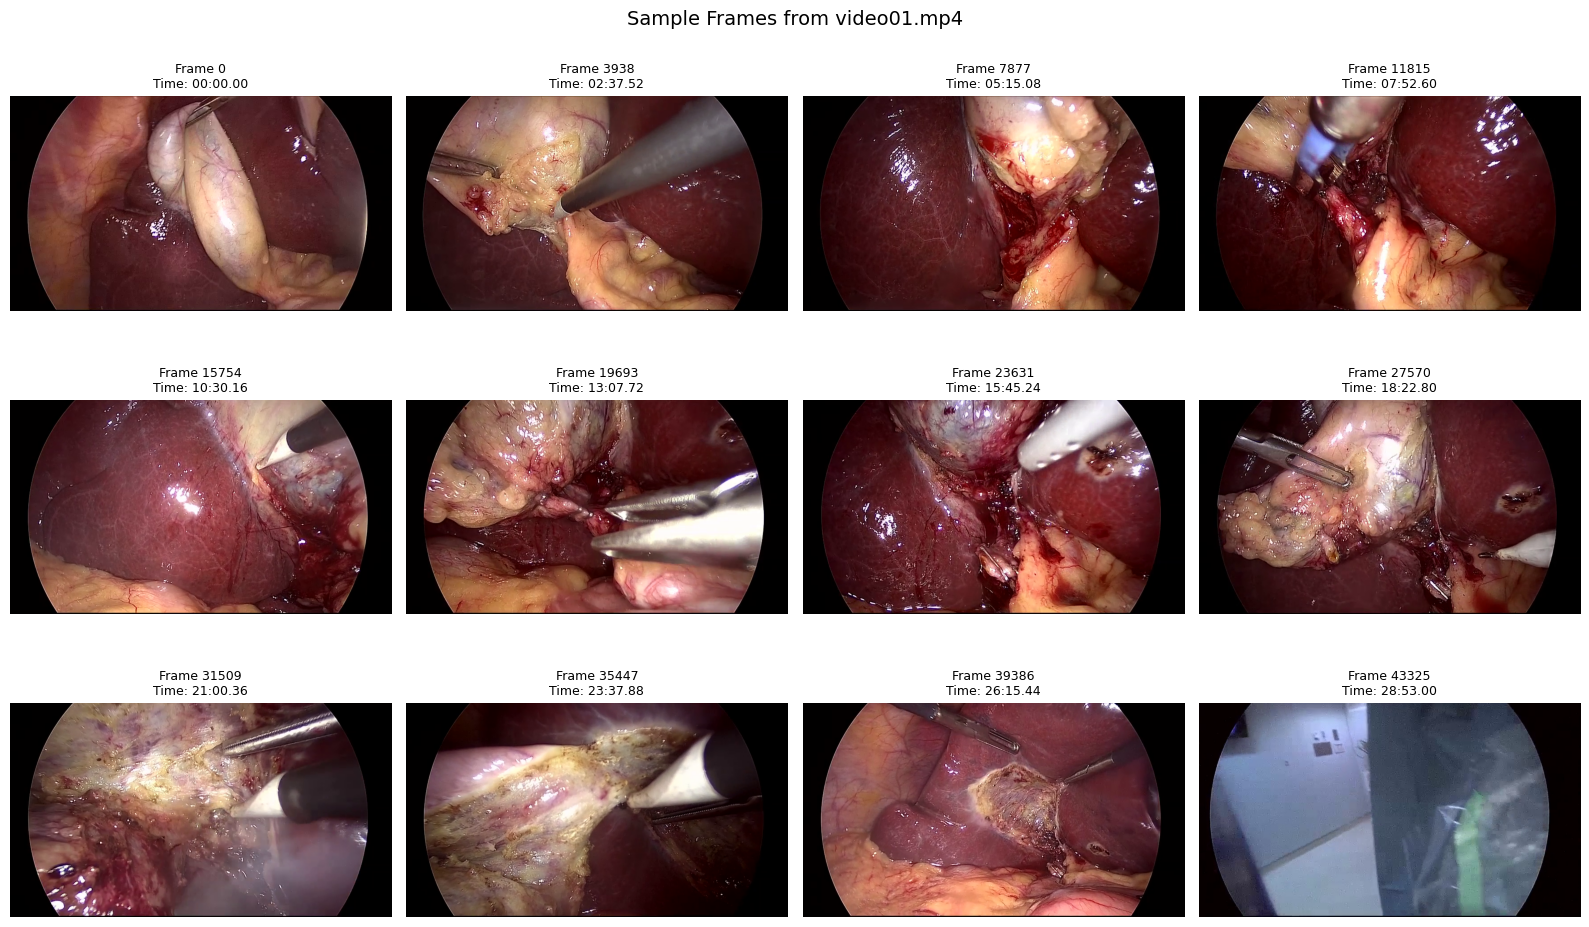


✅ Extracted 12 sample frames
📁 Visualization saved to: results/visualizations/sample_frames.png

📊 Frame Details:
   Frame 1: 854x480 pixels
   Frame 2: 854x480 pixels
   Frame 3: 854x480 pixels


In [8]:
# Cell 4: Extract and visualize sample frames
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

def extract_sample_frames(video_path, n_samples=10):
    """
    Extract evenly-spaced frames from video
    """
    cap = cv2.VideoCapture(str(video_path))
    
    if not cap.isOpened():
        print(f"❌ Error: Could not open video {video_path.name}")
        return []
    
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = total_frames / fps if fps > 0 else 0
    
    print(f"📹 Video: {video_path.name}")
    print(f"   Total frames: {total_frames}")
    print(f"   FPS: {fps:.2f}")
    print(f"   Duration: {duration/60:.2f} minutes")
    
    # Get frame indices evenly spaced
    frame_indices = np.linspace(0, total_frames-1, n_samples, dtype=int)
    
    frames = []
    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if ret:
            frames.append({
                'frame_idx': idx,
                'timestamp': idx / fps if fps > 0 else 0,
                'image': frame
            })
    
    cap.release()
    return frames

# Create results directory
results_dir = Path("results/visualizations")
results_dir.mkdir(parents=True, exist_ok=True)

# Extract samples
video_dir = DATA_DIR / "videos"
videos = sorted(list(video_dir.glob('*.mp4')))

if len(videos) > 0:
    print(f"\n{'='*60}")
    print(f"Extracting frames from: {videos[0].name}")
    print(f"{'='*60}\n")
    
    sample_frames = extract_sample_frames(videos[0], n_samples=12)
    
    if len(sample_frames) > 0:
        # Visualize
        fig, axes = plt.subplots(3, 4, figsize=(16, 10))
        axes = axes.flatten()
        
        for i, frame_data in enumerate(sample_frames):
            # Convert BGR to RGB for matplotlib
            img = cv2.cvtColor(frame_data['image'], cv2.COLOR_BGR2RGB)
            axes[i].imshow(img)
            
            # Format title
            mins = int(frame_data['timestamp'] // 60)
            secs = frame_data['timestamp'] % 60
            axes[i].set_title(
                f"Frame {frame_data['frame_idx']}\n"
                f"Time: {mins:02d}:{secs:05.2f}",
                fontsize=9
            )
            axes[i].axis('off')
        
        plt.suptitle(f"Sample Frames from {videos[0].name}", fontsize=14, y=0.98)
        plt.tight_layout()
        
        # Save figure
        output_path = results_dir / "sample_frames.png"
        plt.savefig(output_path, dpi=150, bbox_inches='tight')
        plt.show()
        
        print(f"\n✅ Extracted {len(sample_frames)} sample frames")
        print(f"📁 Visualization saved to: {output_path}")
        
        # Print frame info
        print(f"\n📊 Frame Details:")
        for i, frame_data in enumerate(sample_frames[:3], 1):
            h, w = frame_data['image'].shape[:2]
            print(f"   Frame {i}: {w}x{h} pixels")
    else:
        print("❌ Failed to extract frames from video")
else:
    print("❌ No videos found!")
    print(f"Expected location: {video_dir}")

In [9]:
# Cell 1: Environment Setup
import os
import sys
from pathlib import Path
import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import pandas as pd

print("="*70)
print("MEDSAM COMPLETE ANALYSIS - PHASE 2")
print("="*70)

BASE_DIR = Path('cholec80')
MEDSAM_DIR = BASE_DIR / 'MedSAM'
CHECKPOINTS_DIR = BASE_DIR / 'checkpoints'
OUTPUT_DIR = BASE_DIR / 'output'

print(f"\n📁 Directory Structure:")
print(f"  Base: {BASE_DIR}")
print(f"  MedSAM: {MEDSAM_DIR}")
print(f"  Checkpoints: {CHECKPOINTS_DIR}")
print(f"  Output: {OUTPUT_DIR}")

MEDSAM COMPLETE ANALYSIS - PHASE 2

📁 Directory Structure:
  Base: cholec80
  MedSAM: cholec80/MedSAM
  Checkpoints: cholec80/checkpoints
  Output: cholec80/output


In [10]:
# Cell 2: Check MedSAM Installation Status
print("\n" + "="*70)
print("1. MEDSAM INSTALLATION CHECK")
print("="*70)

def check_directory_status(dir_path):
    """Check if directory exists and list contents"""
    if dir_path.exists():
        items = list(dir_path.iterdir())
        print(f"✅ {dir_path.name} EXISTS")
        print(f"   Location: {dir_path}")
        print(f"   Items inside: {len(items)}")
        return True, items
    else:
        print(f"❌ {dir_path.name} NOT FOUND")
        print(f"   Expected at: {dir_path}")
        return False, []

# Check MedSAM directory
medsam_exists, medsam_items = check_directory_status(MEDSAM_DIR)

if medsam_exists:
    # Check for key files
    key_files = {
        'README.md': MEDSAM_DIR / 'README.md',
        'MedSAM_Inference.py': MEDSAM_DIR / 'MedSAM_Inference.py',
        'gui.py': MEDSAM_DIR / 'gui.py',
        'tutorial_quickstart.ipynb': MEDSAM_DIR / 'tutorial_quickstart.ipynb'
    }
    
    print(f"\n   Key MedSAM Files:")
    for name, path in key_files.items():
        status = "✅" if path.exists() else "❌"
        print(f"   {status} {name}")


1. MEDSAM INSTALLATION CHECK
✅ MedSAM EXISTS
   Location: cholec80/MedSAM
   Items inside: 19

   Key MedSAM Files:
   ✅ README.md
   ✅ MedSAM_Inference.py
   ✅ gui.py
   ✅ tutorial_quickstart.ipynb


In [11]:
# Cell 3: Check Model Checkpoints
print("\n" + "="*70)
print("2. MODEL CHECKPOINTS CHECK")
print("="*70)

checkpoint_exists, checkpoint_items = check_directory_status(CHECKPOINTS_DIR)

if checkpoint_exists:
    # Analyze checkpoint files
    checkpoint_files = [f for f in checkpoint_items if f.is_file()]
    
    print(f"\n   Checkpoint Files Found: {len(checkpoint_files)}")
    
    for ckpt in checkpoint_files:
        size_mb = ckpt.stat().st_size / (1024**2)
        print(f"\n   📦 {ckpt.name}")
        print(f"      Size: {size_mb:.2f} MB")
        print(f"      Path: {ckpt}")
        
        # Check if it's a PyTorch model
        if ckpt.suffix == '.pth':
            try:
                import torch
                checkpoint = torch.load(ckpt, map_location='cpu')
                print(f"      Type: PyTorch checkpoint")
                
                # Try to get model info
                if isinstance(checkpoint, dict):
                    print(f"      Keys: {list(checkpoint.keys())}")
                    if 'model' in checkpoint:
                        print(f"      Contains 'model' key ✅")
                    if 'state_dict' in checkpoint:
                        print(f"      Contains 'state_dict' key ✅")
                else:
                    print(f"      Direct model weights")
                    
            except Exception as e:
                print(f"      Error loading: {e}")
else:
    print("\n⚠️ No checkpoints directory found!")
    print("   You may need to download MedSAM weights")


2. MODEL CHECKPOINTS CHECK
✅ checkpoints EXISTS
   Location: cholec80/checkpoints
   Items inside: 1

   Checkpoint Files Found: 1

   📦 medsam_vit_b.pth
      Size: 357.67 MB
      Path: cholec80/checkpoints/medsam_vit_b.pth
      Type: PyTorch checkpoint
      Keys: ['image_encoder.neck.0.weight', 'image_encoder.neck.1.weight', 'image_encoder.neck.1.bias', 'image_encoder.neck.2.weight', 'image_encoder.neck.3.weight', 'image_encoder.neck.3.bias', 'image_encoder.patch_embed.proj.weight', 'image_encoder.patch_embed.proj.bias', 'image_encoder.blocks.0.norm1.weight', 'image_encoder.blocks.0.norm1.bias', 'image_encoder.blocks.0.attn.rel_pos_h', 'image_encoder.blocks.0.attn.rel_pos_w', 'image_encoder.blocks.0.attn.qkv.weight', 'image_encoder.blocks.0.attn.qkv.bias', 'image_encoder.blocks.0.attn.proj.weight', 'image_encoder.blocks.0.attn.proj.bias', 'image_encoder.blocks.0.norm2.weight', 'image_encoder.blocks.0.norm2.bias', 'image_encoder.blocks.0.mlp.lin1.weight', 'image_encoder.blocks.0.m

In [12]:
# Cell 4: Explore MedSAM Directory Structure
print("\n" + "="*70)
print("3. MEDSAM DIRECTORY STRUCTURE")
print("="*70)

if medsam_exists:
    def explore_directory(directory, max_depth=3, current_depth=0, prefix=""):
        """Recursively explore directory structure"""
        if current_depth >= max_depth:
            return
        
        items = sorted(list(directory.iterdir()))
        dirs = [item for item in items if item.is_dir() and not item.name.startswith('.')]
        files = [item for item in items if item.is_file() and not item.name.startswith('.')]
        
        # Print directories
        for d in dirs[:10]:  # Limit to first 10
            print(f"{prefix}📁 {d.name}/")
            explore_directory(d, max_depth, current_depth + 1, prefix + "   ")
        
        # Print important files
        important_extensions = ['.py', '.ipynb', '.md', '.pth', '.yaml', '.sh']
        important_files = [f for f in files if f.suffix in important_extensions]
        
        for f in important_files[:5]:  # Limit to first 5
            print(f"{prefix}📄 {f.name}")
    
    print(f"\nMedSAM Structure (up to 3 levels deep):\n")
    explore_directory(MEDSAM_DIR, max_depth=2)


3. MEDSAM DIRECTORY STRUCTURE

MedSAM Structure (up to 3 levels deep):

📁 assets/
📁 comparisons/
   📁 DeepLabV3+/
   📁 SAM/
   📁 nnU-Net/
📁 extensions/
   📁 point_prompt/
   📁 seg_3dnii_sparse_marker/
   📁 text_prompt/
📁 segment_anything/
   📁 modeling/
   📁 utils/
   📄 __init__.py
   📄 automatic_mask_generator.py
   📄 build_sam.py
   📄 predictor.py
📁 utils/
   📄 README.md
   📄 SurfaceDice.py
   📄 ckpt_convert.py
   📄 demo.py
   📄 format_convert.py
📁 work_dir/
   📁 MedSAM/
📄 MedSAM_Inference.py
📄 README.md
📄 gui.py
📄 pre_CT_MR.py
📄 setup.py


In [13]:
# Cell 5: Analyze Python Scripts in MedSAM
print("\n" + "="*70)
print("4. MEDSAM PYTHON SCRIPTS ANALYSIS")
print("="*70)

if medsam_exists:
    # Find all Python files
    python_files = list(MEDSAM_DIR.rglob('*.py'))
    
    print(f"\nTotal Python files found: {len(python_files)}\n")
    
    # Categorize by directory
    file_groups = defaultdict(list)
    for py_file in python_files:
        relative_path = py_file.relative_to(MEDSAM_DIR)
        parent = relative_path.parent
        file_groups[str(parent)].append(py_file.name)
    
    # Show main scripts
    print("Main Scripts:")
    main_scripts = {
        'MedSAM_Inference.py': 'Run inference on images/videos',
        'gui.py': 'Graphical interface for MedSAM',
        'train.py': 'Training script (if exists)',
        'fine_tune.py': 'Fine-tuning script (if exists)'
    }
    
    for script, description in main_scripts.items():
        script_path = MEDSAM_DIR / script
        if script_path.exists():
            size = script_path.stat().st_size / 1024
            print(f"   ✅ {script} ({size:.1f} KB)")
            print(f"      Purpose: {description}")
            
            # Read first few lines to understand usage
            try:
                with open(script_path, 'r', encoding='utf-8') as f:
                    lines = f.readlines()[:30]
                    
                # Look for docstrings or comments
                docstring = []
                in_docstring = False
                for line in lines:
                    if '"""' in line or "'''" in line:
                        in_docstring = not in_docstring
                        if '"""' in line or "'''" in line:
                            docstring.append(line.strip())
                    elif in_docstring:
                        docstring.append(line.strip())
                    elif line.strip().startswith('#') and len(docstring) == 0:
                        docstring.append(line.strip())
                
                if docstring:
                    print(f"      Info: {' '.join(docstring[:3])[:100]}...")
                        
            except Exception as e:
                print(f"      (Could not read file)")
            print()
        else:
            print(f"   ❌ {script} (not found)")


4. MEDSAM PYTHON SCRIPTS ANALYSIS

Total Python files found: 39

Main Scripts:
   ✅ MedSAM_Inference.py (4.4 KB)
      Purpose: Run inference on images/videos
      Info: # -*- coding: utf-8 -*- """ usage example:...

   ✅ gui.py (9.2 KB)
      Purpose: Graphical interface for MedSAM
      Info: # -*- coding: utf-8 -*-...

   ❌ train.py (not found)
   ❌ fine_tune.py (not found)


In [14]:
# Cell 7: Check Output Directory
print("\n" + "="*70)
print("6. OUTPUT DIRECTORY ANALYSIS")
print("="*70)

output_exists, output_items = check_directory_status(OUTPUT_DIR)

if output_exists:
    print(f"\n   Subdirectories in output:")
    
    output_dirs = [item for item in output_items if item.is_dir()]
    
    for out_dir in output_dirs:
        print(f"\n   📁 {out_dir.name}/")
        
        # Count contents
        frames_dir = out_dir / 'frames'
        masks_dir = out_dir / 'masks'
        summary_file = out_dir / 'summary.json'
        
        if frames_dir.exists():
            frame_count = len(list(frames_dir.glob('*.jpg'))) + len(list(frames_dir.glob('*.png')))
            print(f"      Frames: {frame_count:,}")
        
        if masks_dir.exists():
            mask_count = len(list(masks_dir.glob('*.png')))
            print(f"      Masks: {mask_count:,}")
        
        if summary_file.exists():
            print(f"      Summary: ✅")
        
        # Calculate total size
        total_size = sum(f.stat().st_size for f in out_dir.rglob('*') if f.is_file())
        print(f"      Total size: {total_size / (1024**2):.2f} MB")


6. OUTPUT DIRECTORY ANALYSIS
✅ output EXISTS
   Location: cholec80/output
   Items inside: 1

   Subdirectories in output:

   📁 video01_medsam/
      Frames: 1,185
      Masks: 2,878
      Summary: ✅
      Total size: 163.61 MB


In [15]:
# Cell 8: Deep Dive into video01_medsam Output
print("\n" + "="*70)
print("7. DETAILED ANALYSIS: video01_medsam")
print("="*70)

video01_output = OUTPUT_DIR / 'video01_medsam'

if video01_output.exists():
    print(f"\n✅ Found video01_medsam output\n")
    
    frames_dir = video01_output / 'frames'
    masks_dir = video01_output / 'masks'
    summary_file = video01_output / 'summary.json'
    
    # Analyze frames
    if frames_dir.exists():
        frame_files = sorted(list(frames_dir.glob('*.jpg')) + list(frames_dir.glob('*.png')))
        print(f"📸 Frames Analysis:")
        print(f"   Total frames: {len(frame_files):,}")
        
        if len(frame_files) > 0:
            # Sample some frames to get info
            sample_frame = cv2.imread(str(frame_files[0]))
            h, w = sample_frame.shape[:2]
            print(f"   Resolution: {w}x{h}")
            
            # Frame numbering pattern
            frame_numbers = []
            for f in frame_files[:10]:
                # Extract frame number from filename
                import re
                match = re.search(r'frame_(\d+)', f.stem)
                if match:
                    frame_numbers.append(int(match.group(1)))
            
            if len(frame_numbers) > 1:
                intervals = [frame_numbers[i+1] - frame_numbers[i] for i in range(len(frame_numbers)-1)]
                avg_interval = np.mean(intervals) if intervals else 0
                print(f"   Frame sampling interval: ~{avg_interval:.0f} frames")
            
            # Show frame range
            first_frame = frame_files[0].stem
            last_frame = frame_files[-1].stem
            print(f"   First frame: {first_frame}")
            print(f"   Last frame: {last_frame}")
    
    # Analyze masks
    if masks_dir.exists():
        mask_files = sorted(list(masks_dir.glob('*.png')))
        print(f"\n🎭 Masks Analysis:")
        print(f"   Total masks: {len(mask_files):,}")
        
        if len(mask_files) > 0:
            # Analyze mask naming pattern
            mask_names = [m.stem for m in mask_files[:20]]
            print(f"   Sample mask names:")
            for name in mask_names[:5]:
                print(f"      {name}")
            
            # Count masks per frame
            mask_counts = defaultdict(int)
            for mask_file in mask_files:
                # Extract base frame name
                match = re.search(r'frame_(\d+)', mask_file.stem)
                if match:
                    frame_num = match.group(1)
                    mask_counts[frame_num] += 1
            
            # Statistics
            masks_per_frame = list(mask_counts.values())
            print(f"\n   Masks per frame statistics:")
            print(f"      Mean: {np.mean(masks_per_frame):.2f}")
            print(f"      Median: {np.median(masks_per_frame):.0f}")
            print(f"      Min: {np.min(masks_per_frame):.0f}")
            print(f"      Max: {np.max(masks_per_frame):.0f}")
            
            # Show distribution
            unique_counts = sorted(set(masks_per_frame))
            print(f"\n   Distribution:")
            for count in unique_counts[:10]:
                num_frames = sum(1 for x in masks_per_frame if x == count)
                print(f"      {count} mask(s): {num_frames} frames")
    
    # Analyze summary file
    if summary_file.exists():
        print(f"\n📋 Summary File:")
        try:
            with open(summary_file, 'r') as f:
                summary = json.load(f)
            
            print(f"   ✅ Successfully loaded summary.json")
            print(f"   Keys: {list(summary.keys()) if isinstance(summary, dict) else 'List format'}")
            
            # Show first entry
            if isinstance(summary, dict):
                first_key = list(summary.keys())[0]
                print(f"\n   Sample entry (key: {first_key}):")
                print(f"   {json.dumps(summary[first_key], indent=6)}")
            elif isinstance(summary, list) and len(summary) > 0:
                print(f"\n   Sample entry (index 0):")
                print(f"   {json.dumps(summary[0], indent=6)}")
                
        except Exception as e:
            print(f"   ❌ Error reading summary: {e}")
else:
    print(f"\n❌ video01_medsam output not found")


7. DETAILED ANALYSIS: video01_medsam

✅ Found video01_medsam output

📸 Frames Analysis:
   Total frames: 1,185
   Resolution: 854x480
   Frame sampling interval: ~25 frames
   First frame: frame_000000
   Last frame: frame_029600

🎭 Masks Analysis:
   Total masks: 2,878
   Sample mask names:
      frame_000000_mask_0
      frame_000025_mask_0
      frame_000025_mask_1
      frame_000050_mask_0
      frame_000050_mask_1

   Masks per frame statistics:
      Mean: 2.43
      Median: 2
      Min: 1
      Max: 11

   Distribution:
      1 mask(s): 479 frames
      2 mask(s): 285 frames
      3 mask(s): 160 frames
      4 mask(s): 112 frames
      5 mask(s): 67 frames
      6 mask(s): 39 frames
      7 mask(s): 25 frames
      8 mask(s): 11 frames
      9 mask(s): 3 frames
      10 mask(s): 2 frames

📋 Summary File:
   ✅ Successfully loaded summary.json
   Keys: ['video_name', 'total_frames', 'processed_frames', 'frames_with_blood', 'total_regions']

   Sample entry (key: video_name):
   "


8. VISUALIZING MEDSAM RESULTS


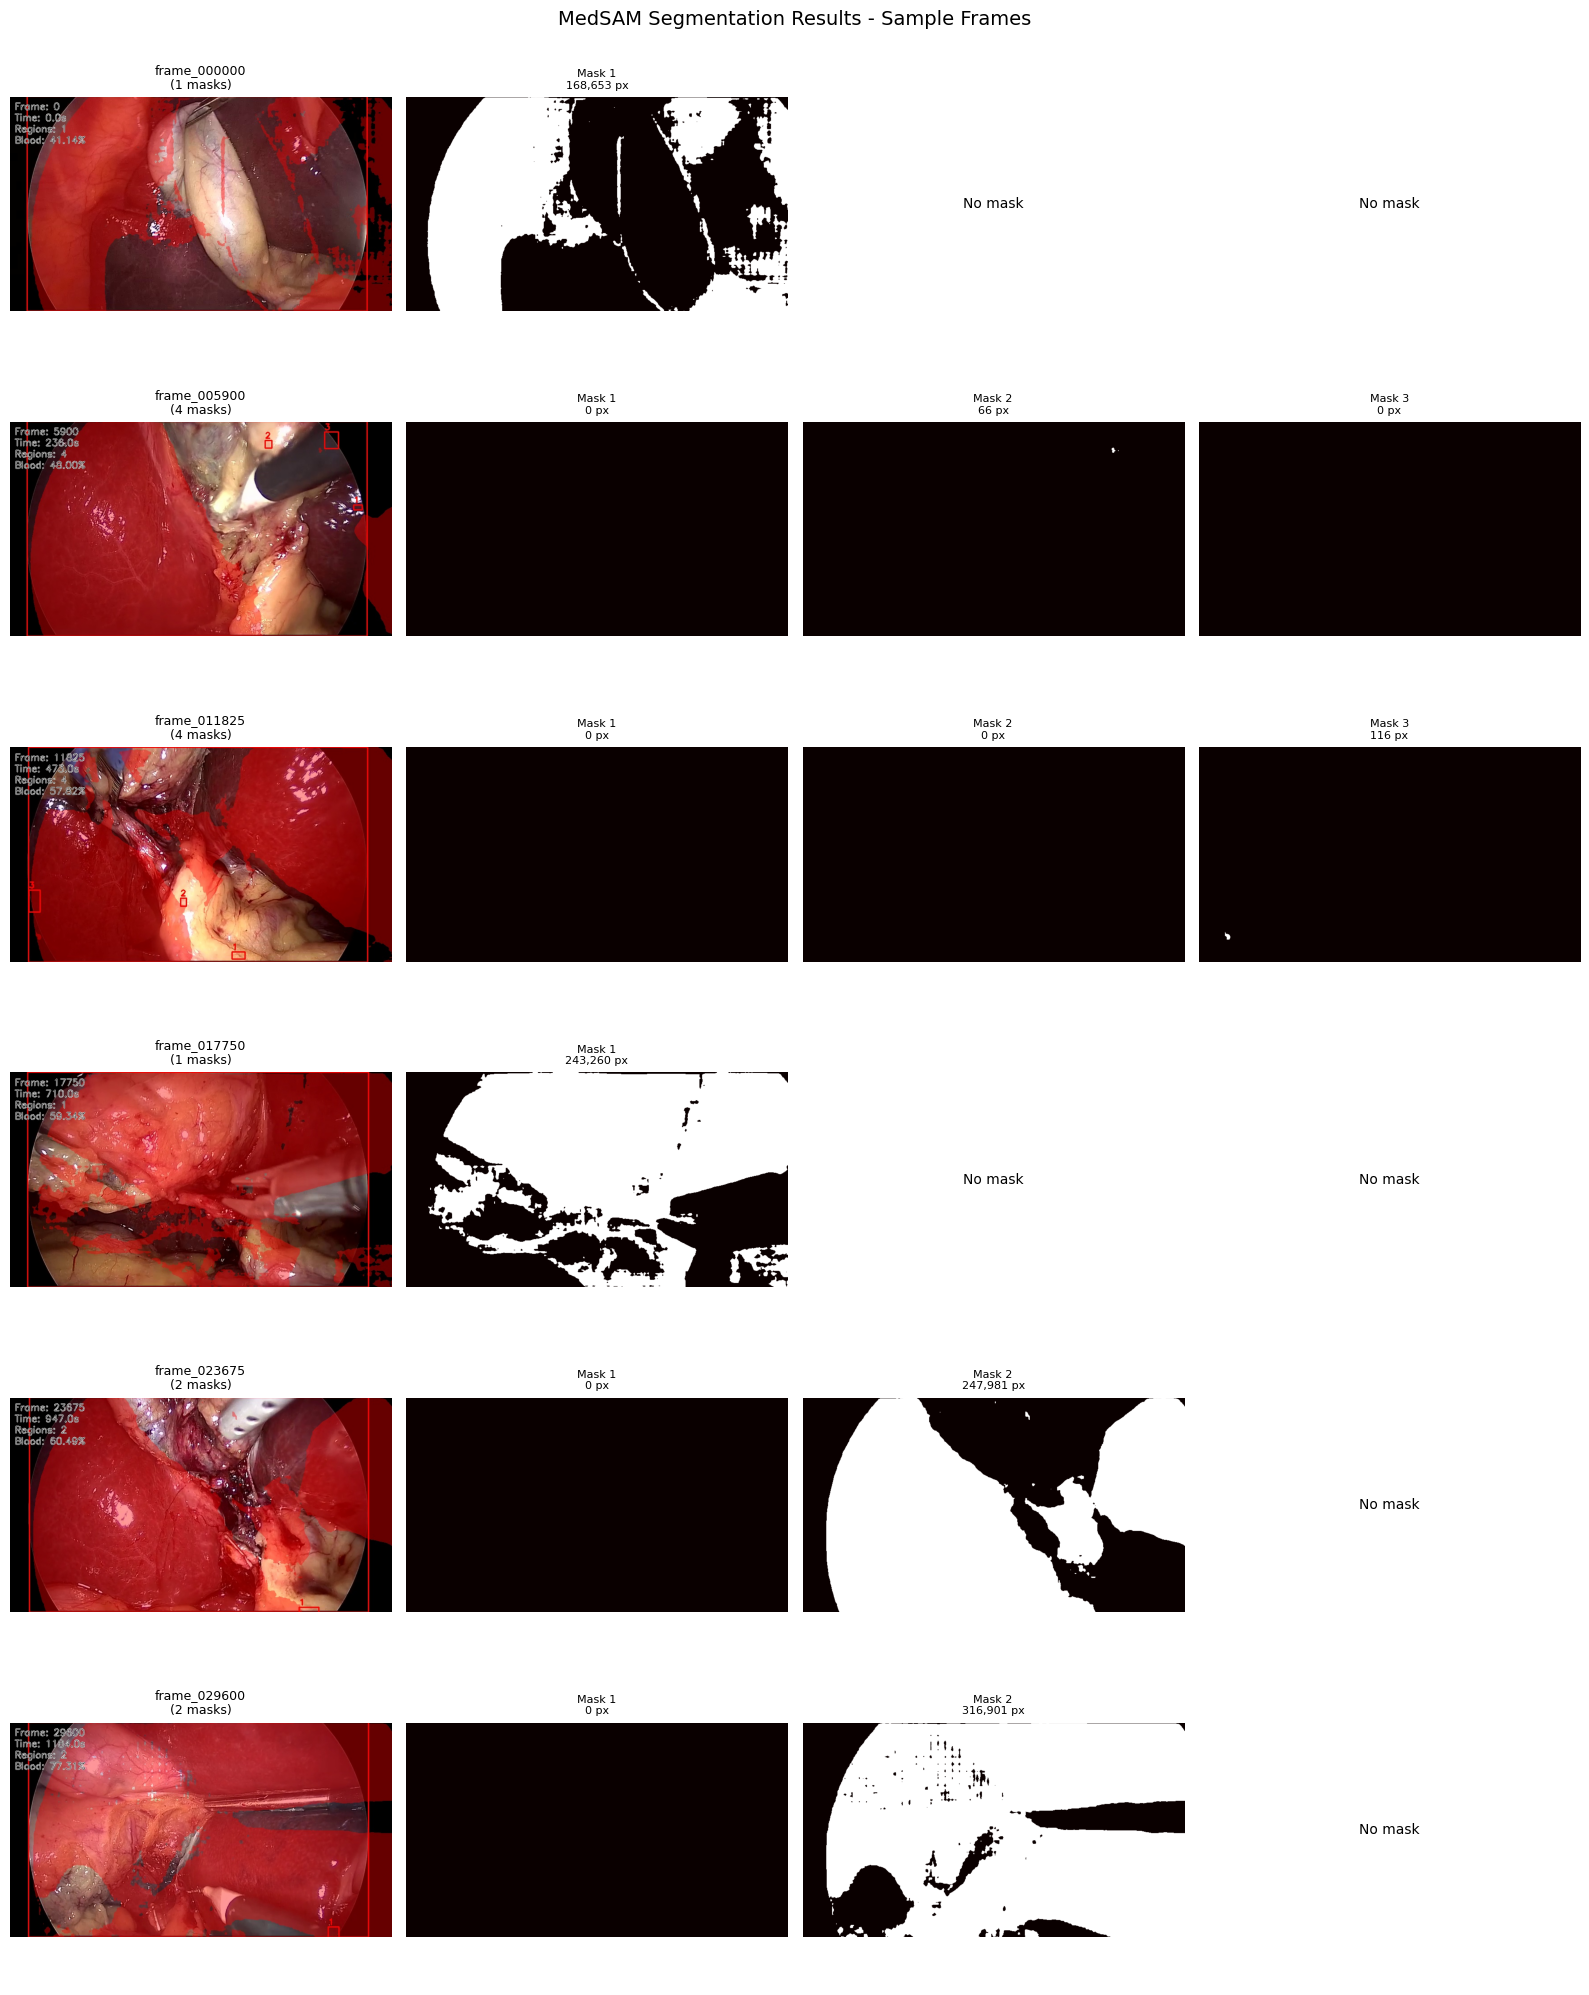


✅ Visualization saved: medsam_results_overview.png


In [16]:
# Cell 9: Visualize Sample MedSAM Results
print("\n" + "="*70)
print("8. VISUALIZING MEDSAM RESULTS")
print("="*70)

if video01_output.exists() and frames_dir.exists() and masks_dir.exists():
    
    def load_frame_and_masks(frame_file, masks_dir):
        """Load a frame and all its associated masks"""
        # Load frame
        frame = cv2.imread(str(frame_file))
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Find all masks for this frame
        frame_base = frame_file.stem  # e.g., "frame_007877"
        mask_pattern = f"{frame_base}_mask_*.png"
        mask_files = sorted(list(masks_dir.glob(mask_pattern)))
        
        # Load all masks
        masks = []
        for mask_file in mask_files:
            mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
            masks.append(mask)
        
        return frame_rgb, masks, mask_files
    
    # Select frames to visualize (evenly spaced)
    all_frames = sorted(list(frames_dir.glob('*.jpg')))
    
    if len(all_frames) > 0:
        # Pick 6 frames evenly spaced
        indices = np.linspace(0, len(all_frames)-1, 6, dtype=int)
        sample_frames = [all_frames[i] for i in indices]
        
        fig, axes = plt.subplots(6, 4, figsize=(16, 20))
        
        for i, frame_file in enumerate(sample_frames):
            frame_rgb, masks, mask_paths = load_frame_and_masks(frame_file, masks_dir)
            
            # Original frame
            axes[i, 0].imshow(frame_rgb)
            axes[i, 0].set_title(f'{frame_file.stem}\n({len(masks)} masks)', fontsize=9)
            axes[i, 0].axis('off')
            
            # Show up to 3 masks
            for j in range(3):
                if j < len(masks):
                    axes[i, j+1].imshow(masks[j], cmap='hot')
                    axes[i, j+1].set_title(f'Mask {j+1}\n{np.sum(masks[j]>0):,} px', fontsize=8)
                else:
                    axes[i, j+1].text(0.5, 0.5, 'No mask', 
                                     ha='center', va='center', fontsize=10)
                axes[i, j+1].axis('off')
        
        plt.suptitle('MedSAM Segmentation Results - Sample Frames', fontsize=14, y=0.995)
        plt.tight_layout()
        plt.savefig('medsam_results_overview.png', dpi=150, bbox_inches='tight')
        plt.show()
        
        print("\n✅ Visualization saved: medsam_results_overview.png")
    else:
        print("\n❌ No frame files found to visualize")
else:
    print("\n⚠️ Cannot visualize - missing frames or masks directory")


9. MASK QUALITY ANALYSIS
Analyzing all masks (this may take a moment)...

Analyzed 500 masks

📊 Mask Statistics:
   Masks with content (>100px): 322 (64.4%)

   Area (pixels):
      Mean: 52,755
      Median: 278
      Std Dev: 87,278
      Min: 0
      Max: 291,659

   Frame coverage (%):
      Mean: 12.87%
      Median: 0.07%
      Max: 71.15%


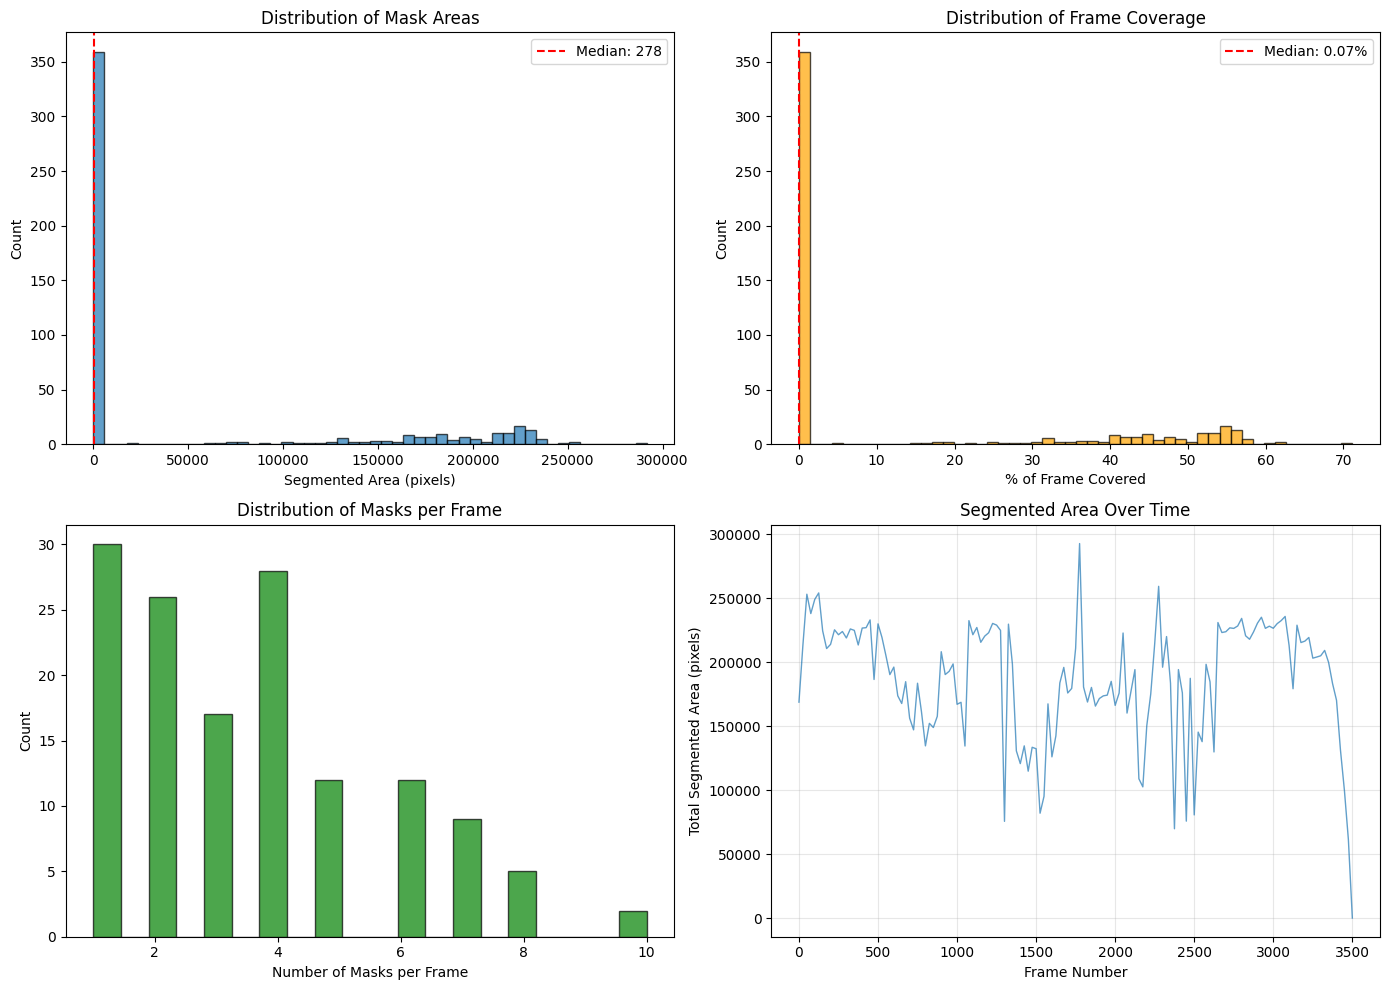


✅ Quality analysis saved: mask_quality_analysis.png
✅ Data saved: mask_analysis_data.csv


In [17]:
# Cell 10: Analyze Mask Quality and Content
print("\n" + "="*70)
print("9. MASK QUALITY ANALYSIS")
print("="*70)

if video01_output.exists() and masks_dir.exists():
    
    print("Analyzing all masks (this may take a moment)...\n")
    
    mask_files = sorted(list(masks_dir.glob('*.png')))
    
    # Analyze each mask
    mask_data = []
    
    for mask_file in mask_files[:500]:  # Analyze first 500 masks
        mask = cv2.imread(str(mask_file), cv2.IMREAD_GRAYSCALE)
        
        if mask is not None:
            total_pixels = mask.shape[0] * mask.shape[1]
            segmented_pixels = np.sum(mask > 0)
            percentage = 100 * segmented_pixels / total_pixels
            
            # Extract frame number
            match = re.search(r'frame_(\d+)', mask_file.stem)
            frame_num = int(match.group(1)) if match else -1
            
            # Extract mask index
            match = re.search(r'mask_(\d+)', mask_file.stem)
            mask_idx = int(match.group(1)) if match else -1
            
            mask_data.append({
                'filename': mask_file.name,
                'frame_number': frame_num,
                'mask_index': mask_idx,
                'area_pixels': segmented_pixels,
                'percentage': percentage,
                'has_content': segmented_pixels > 100
            })
    
    # Create DataFrame
    df_masks = pd.DataFrame(mask_data)
    
    print(f"Analyzed {len(df_masks)} masks\n")
    
    # Statistics
    print("📊 Mask Statistics:")
    print(f"   Masks with content (>100px): {sum(df_masks['has_content'])} ({100*sum(df_masks['has_content'])/len(df_masks):.1f}%)")
    print(f"\n   Area (pixels):")
    print(f"      Mean: {df_masks['area_pixels'].mean():,.0f}")
    print(f"      Median: {df_masks['area_pixels'].median():,.0f}")
    print(f"      Std Dev: {df_masks['area_pixels'].std():,.0f}")
    print(f"      Min: {df_masks['area_pixels'].min():,.0f}")
    print(f"      Max: {df_masks['area_pixels'].max():,.0f}")
    
    print(f"\n   Frame coverage (%):")
    print(f"      Mean: {df_masks['percentage'].mean():.2f}%")
    print(f"      Median: {df_masks['percentage'].median():.2f}%")
    print(f"      Max: {df_masks['percentage'].max():.2f}%")
    
    # Plot distributions
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Area distribution
    axes[0, 0].hist(df_masks['area_pixels'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Segmented Area (pixels)')
    axes[0, 0].set_ylabel('Count')
    axes[0, 0].set_title('Distribution of Mask Areas')
    axes[0, 0].axvline(df_masks['area_pixels'].median(), color='red', 
                       linestyle='--', label=f'Median: {df_masks["area_pixels"].median():.0f}')
    axes[0, 0].legend()
    
    # Percentage distribution
    axes[0, 1].hist(df_masks['percentage'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_xlabel('% of Frame Covered')
    axes[0, 1].set_ylabel('Count')
    axes[0, 1].set_title('Distribution of Frame Coverage')
    axes[0, 1].axvline(df_masks['percentage'].median(), color='red', 
                       linestyle='--', label=f'Median: {df_masks["percentage"].median():.2f}%')
    axes[0, 1].legend()
    
    # Masks per frame
    masks_per_frame = df_masks.groupby('frame_number').size()
    axes[1, 0].hist(masks_per_frame, bins=20, edgecolor='black', alpha=0.7, color='green')
    axes[1, 0].set_xlabel('Number of Masks per Frame')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].set_title('Distribution of Masks per Frame')
    
    # Area vs Frame number (temporal pattern)
    frame_area = df_masks.groupby('frame_number')['area_pixels'].sum()
    axes[1, 1].plot(frame_area.index, frame_area.values, alpha=0.7, linewidth=1)
    axes[1, 1].set_xlabel('Frame Number')
    axes[1, 1].set_ylabel('Total Segmented Area (pixels)')
    axes[1, 1].set_title('Segmented Area Over Time')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('mask_quality_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✅ Quality analysis saved: mask_quality_analysis.png")
    
    # Save data
    df_masks.to_csv('mask_analysis_data.csv', index=False)
    print("✅ Data saved: mask_analysis_data.csv")

In [18]:
# Cell 11: Test if MedSAM can be imported and run
print("\n" + "="*70)
print("10. TESTING MEDSAM FUNCTIONALITY")
print("="*70)

# Add MedSAM to Python path
if medsam_exists:
    sys.path.insert(0, str(MEDSAM_DIR))
    print(f"✅ Added MedSAM to Python path\n")

# Try to import MedSAM components
print("Attempting to import MedSAM modules...\n")

try:
    # Check for segment_anything
    import segment_anything
    print("✅ segment_anything package available")
    print(f"   Version: {segment_anything.__version__ if hasattr(segment_anything, '__version__') else 'Unknown'}")
except ImportError as e:
    print(f"❌ segment_anything not available: {e}")
    print("   You may need to install: pip install git+https://github.com/facebookresearch/segment-anything.git")

try:
    import torch
    print(f"\n✅ PyTorch available")
    print(f"   Version: {torch.__version__}")
    print(f"   CUDA available: {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        print(f"   CUDA version: {torch.version.cuda}")
        print(f"   GPU: {torch.cuda.get_device_name(0)}")
except ImportError:
    print(f"\n❌ PyTorch not available")

# Check if we can load the model
print("\n" + "-"*70)
print("Attempting to load MedSAM checkpoint...\n")

checkpoint_path = CHECKPOINTS_DIR / 'medsam_vit_b.pth'

if checkpoint_path.exists():
    try:
        import torch
        checkpoint = torch.load(checkpoint_path, map_location='cpu')
        print(f"✅ Successfully loaded checkpoint")
        
        if isinstance(checkpoint, dict):
            print(f"   Checkpoint type: Dictionary")
            print(f"   Keys: {list(checkpoint.keys())}")
            
            # Check for model weights
            if 'model' in checkpoint:
                print(f"   Model weights found under 'model' key")
                num_params = sum(p.numel() for p in checkpoint['model'].values() if isinstance(p, torch.Tensor))
                print(f"   Estimated parameters: {num_params:,}")
            elif 'state_dict' in checkpoint:
                print(f"   Model weights found under 'state_dict' key")
        else:
            print(f"   Checkpoint type: Direct model")
            
        print(f"\n✅ Checkpoint is valid and loadable")
        
    except Exception as e:
        print(f"❌ Error loading checkpoint: {e}")
else:
    print(f"❌ Checkpoint not found at: {checkpoint_path}")
    print("\n   You need to download MedSAM weights:")
    print("   1. Visit: https://github.com/bowang-lab/MedSAM")
    print("   2. Download medsam_vit_b.pth")
    print(f"   3. Place in: {CHECKPOINTS_DIR}/")


10. TESTING MEDSAM FUNCTIONALITY
✅ Added MedSAM to Python path

Attempting to import MedSAM modules...

✅ segment_anything package available
   Version: Unknown

✅ PyTorch available
   Version: 2.9.0+cu128
   CUDA available: True
   CUDA version: 12.8
   GPU: NVIDIA H100 80GB HBM3

----------------------------------------------------------------------
Attempting to load MedSAM checkpoint...

✅ Successfully loaded checkpoint
   Checkpoint type: Dictionary
   Keys: ['image_encoder.neck.0.weight', 'image_encoder.neck.1.weight', 'image_encoder.neck.1.bias', 'image_encoder.neck.2.weight', 'image_encoder.neck.3.weight', 'image_encoder.neck.3.bias', 'image_encoder.patch_embed.proj.weight', 'image_encoder.patch_embed.proj.bias', 'image_encoder.blocks.0.norm1.weight', 'image_encoder.blocks.0.norm1.bias', 'image_encoder.blocks.0.attn.rel_pos_h', 'image_encoder.blocks.0.attn.rel_pos_w', 'image_encoder.blocks.0.attn.qkv.weight', 'image_encoder.blocks.0.attn.qkv.bias', 'image_encoder.blocks.0.attn